<a href="https://colab.research.google.com/github/Kishanmvs/Vision-Transformer-ViT-on-CIFAR-10/blob/main/vit_cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vision Transformer (ViT) on CIFAR-10

A simple from-scratch implementation of Vision Transformer for image classification.

**Dataset**: CIFAR-10 (10 classes, 32×32 images)  
**Model**: Mini-ViT built with PyTorch  
**Goal**: Understand ViT architecture and train it end-to-end

---
### ViT Architecture Overview
1. Split image into fixed-size patches
2. Linearly embed each patch
3. Add positional embeddings + CLS token
4. Pass through Transformer encoder blocks
5. Classify using CLS token output

## Step 1: Install & Import Libraries

In [1]:
# Uncomment if not installed
!pip install torch torchvision matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Step 2: Load CIFAR-10 Dataset

In [3]:
# Data transforms
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

# Load datasets
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128,
                                           shuffle=True, num_workers=2)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=128,
                                           shuffle=False, num_workers=2)

classes = ('plane','car','bird','cat','deer',
           'dog','frog','horse','ship','truck')

print(f'Train samples: {len(trainset)} | Test samples: {len(testset)}')

100%|██████████| 170M/170M [13:48<00:00, 206kB/s]


Train samples: 50000 | Test samples: 10000


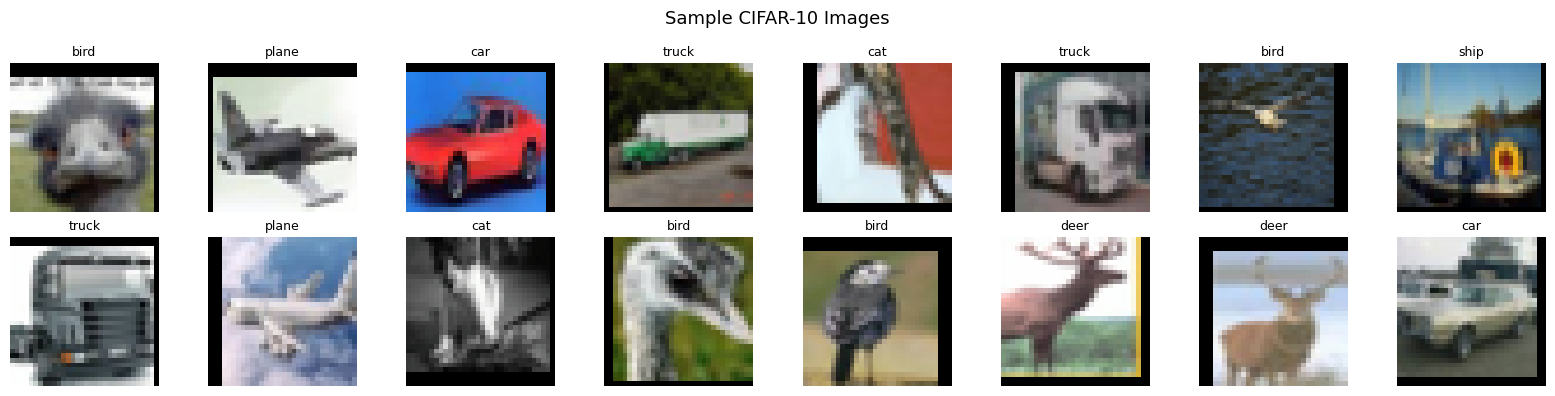

In [4]:
# Visualize some training images
def imshow(img):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1)
    img = img * std + mean
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.axis('off')

dataiter = iter(trainloader)
images, labels = next(dataiter)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(np.transpose((images[i].numpy() * np.array([0.2023,0.1994,0.2010]).reshape(3,1,1)
                             + np.array([0.4914,0.4822,0.4465]).reshape(3,1,1)).clip(0,1), (1,2,0)))
    ax.set_title(classes[labels[i]], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontsize=13)
plt.tight_layout()
plt.show()

## Step 3: Build the Vision Transformer

We build a **mini ViT** suited for 32×32 images:
- Patch size: 4×4 → 64 patches
- Embedding dim: 128
- Transformer blocks: 6
- Attention heads: 4

In [5]:
# --- Patch Embedding ---
class PatchEmbedding(nn.Module):
    """
    Splits the image into patches and projects each patch
    to an embedding vector.
    """
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        # Conv2d with stride=patch_size acts as a patch extractor + linear projection
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: (B, C, H, W) → (B, embed_dim, H/P, W/P) → (B, num_patches, embed_dim)
        x = self.proj(x)              # (B, embed_dim, n, n)
        x = x.flatten(2)             # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)        # (B, num_patches, embed_dim)
        return x

In [6]:
# --- Multi-Head Self-Attention ---
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads,
                                           dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out, _ = self.attn(x, x, x)
        return self.dropout(out)

In [7]:
# --- Transformer Encoder Block ---
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        mlp_dim = embed_dim * mlp_ratio
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        # Pre-norm residual connections
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

In [8]:
# --- Full Vision Transformer ---
class VisionTransformer(nn.Module):
    def __init__(self,
                 img_size=32,
                 patch_size=4,
                 in_channels=3,
                 num_classes=10,
                 embed_dim=128,
                 depth=6,
                 num_heads=4,
                 mlp_ratio=4,
                 dropout=0.1):
        super().__init__()

        # 1. Patch Embedding
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches

        # 2. Learnable CLS token & positional embeddings
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop  = nn.Dropout(dropout)

        # 3. Transformer Encoder
        self.blocks = nn.Sequential(*[
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        # 4. Classification Head
        self.head = nn.Linear(embed_dim, num_classes)

        # Weight initialization
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        B = x.size(0)

        # Patch embedding: (B, num_patches, embed_dim)
        x = self.patch_embed(x)

        # Prepend CLS token
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)       # (B, num_patches+1, embed_dim)

        # Add positional embedding
        x = self.pos_drop(x + self.pos_embed)

        # Transformer blocks
        x = self.blocks(x)
        x = self.norm(x)

        # Classify using CLS token
        cls_out = x[:, 0]                    # (B, embed_dim)
        return self.head(cls_out)            # (B, num_classes)


# Instantiate model
model = VisionTransformer().to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model Parameters: {total_params:,}')
print(model)

Model Parameters: 1,205,898
VisionTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
  )
  (pos_drop): Dropout(p=0.1, inplace=False)
  (blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadSelfAttention(
        (attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_af

## Step 4: Training Setup

In [9]:
NUM_EPOCHS = 20

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print('Criterion : CrossEntropyLoss')
print('Optimizer : AdamW  (lr=3e-4)')
print('Scheduler : CosineAnnealingLR')

Criterion : CrossEntropyLoss
Optimizer : AdamW  (lr=3e-4)
Scheduler : CosineAnnealingLR


## Step 5: Train the Model

In [10]:
train_losses, test_accuracies = [], []

for epoch in range(1, NUM_EPOCHS + 1):
    # ---- Training ----
    model.train()
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(trainloader)
    train_losses.append(avg_loss)
    scheduler.step()

    # ---- Evaluation ----
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    acc = 100. * correct / total
    test_accuracies.append(acc)

    print(f'Epoch [{epoch:2d}/{NUM_EPOCHS}]  '
          f'Loss: {avg_loss:.4f}  '
          f'Test Acc: {acc:.2f}%')

print('\nTraining complete!')

Epoch [ 1/20]  Loss: 1.7838  Test Acc: 42.33%
Epoch [ 2/20]  Loss: 1.4806  Test Acc: 49.87%
Epoch [ 3/20]  Loss: 1.3486  Test Acc: 53.18%
Epoch [ 4/20]  Loss: 1.2563  Test Acc: 57.91%
Epoch [ 5/20]  Loss: 1.1867  Test Acc: 60.66%
Epoch [ 6/20]  Loss: 1.1289  Test Acc: 62.28%
Epoch [ 7/20]  Loss: 1.0874  Test Acc: 63.22%
Epoch [ 8/20]  Loss: 1.0410  Test Acc: 64.59%
Epoch [ 9/20]  Loss: 1.0078  Test Acc: 66.59%
Epoch [10/20]  Loss: 0.9702  Test Acc: 67.41%
Epoch [11/20]  Loss: 0.9440  Test Acc: 67.87%
Epoch [12/20]  Loss: 0.9130  Test Acc: 68.83%
Epoch [13/20]  Loss: 0.8823  Test Acc: 70.69%
Epoch [14/20]  Loss: 0.8663  Test Acc: 70.12%
Epoch [15/20]  Loss: 0.8447  Test Acc: 71.54%
Epoch [16/20]  Loss: 0.8282  Test Acc: 72.02%
Epoch [17/20]  Loss: 0.8121  Test Acc: 72.57%
Epoch [18/20]  Loss: 0.8009  Test Acc: 72.57%
Epoch [19/20]  Loss: 0.7885  Test Acc: 72.48%
Epoch [20/20]  Loss: 0.7866  Test Acc: 72.53%

Training complete!


## Step 6: Plot Training Curves

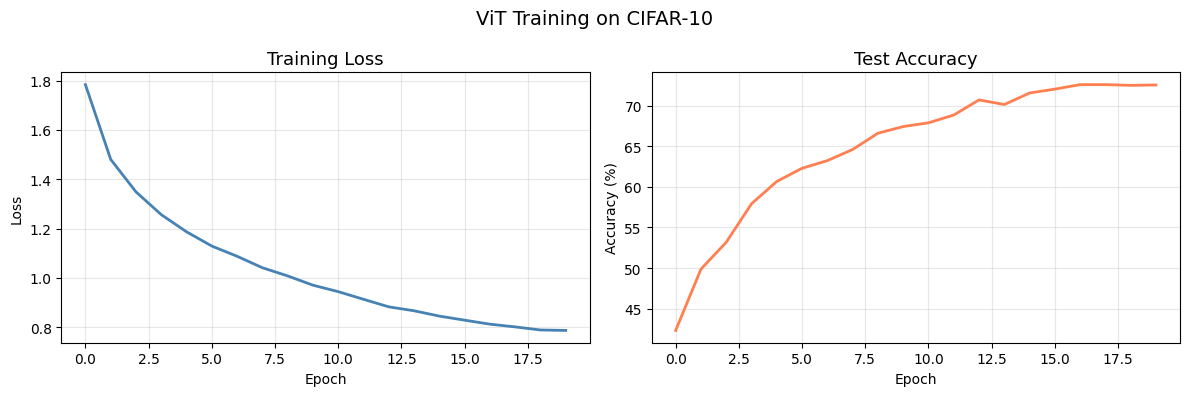

Best Test Accuracy: 72.57%


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, color='steelblue', linewidth=2)
ax1.set_title('Training Loss', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(test_accuracies, color='coral', linewidth=2)
ax2.set_title('Test Accuracy', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, alpha=0.3)

plt.suptitle('ViT Training on CIFAR-10', fontsize=14)
plt.tight_layout()
plt.show()
print(f'Best Test Accuracy: {max(test_accuracies):.2f}%')

## Step 7: Per-Class Accuracy

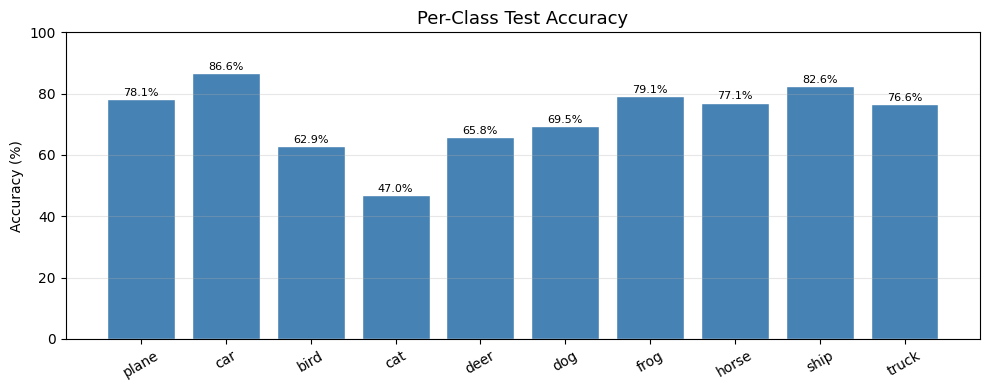

In [12]:
class_correct = [0] * 10
class_total   = [0] * 10

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        for i in range(len(labels)):
            label = labels[i].item()
            class_correct[label] += (predicted[i] == labels[i]).item()
            class_total[label]   += 1

per_class_acc = [100 * class_correct[i] / class_total[i] for i in range(10)]

plt.figure(figsize=(10, 4))
bars = plt.bar(classes, per_class_acc, color='steelblue', edgecolor='white')
plt.ylim(0, 100)
plt.title('Per-Class Test Accuracy', fontsize=13)
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=30)
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', fontsize=8)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 8: Visualize Predictions

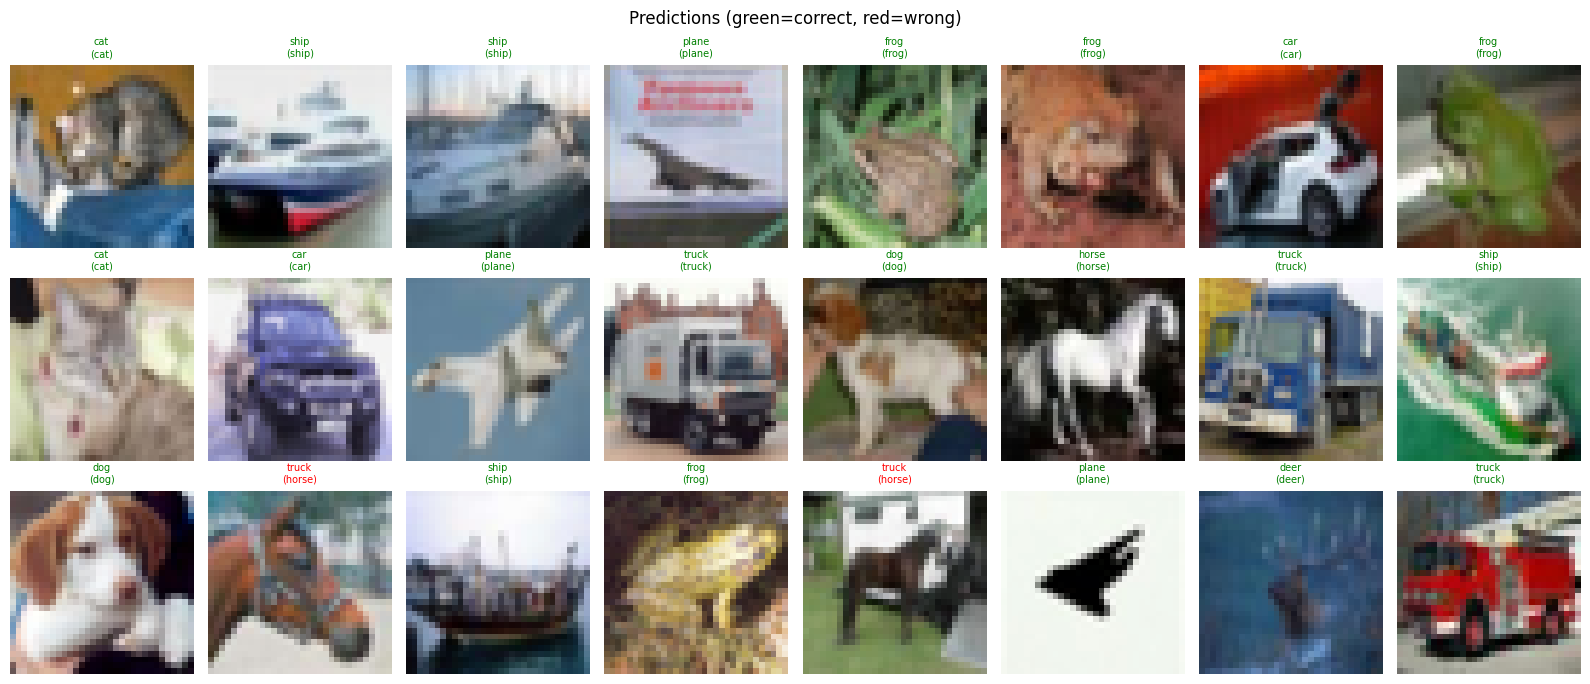

In [13]:
model.eval()
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted = outputs.max(1)

images = images.cpu()
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1)

fig, axes = plt.subplots(3, 8, figsize=(16, 7))
for i, ax in enumerate(axes.flat):
    img = (images[i] * std + mean).clamp(0,1).numpy().transpose(1,2,0)
    ax.imshow(img)
    pred = classes[predicted[i].item()]
    true = classes[labels[i].item()]
    color = 'green' if pred == true else 'red'
    ax.set_title(f'{pred}\n({true})', fontsize=7, color=color)
    ax.axis('off')

plt.suptitle('Predictions (green=correct, red=wrong)', fontsize=12)
plt.tight_layout()
plt.show()

## Step 9: Save & Load Model

In [14]:
# Save
torch.save(model.state_dict(), 'vit_cifar10.pth')
print('Model saved to vit_cifar10.pth')

# Load (example)
# model2 = VisionTransformer().to(device)
# model2.load_state_dict(torch.load('vit_cifar10.pth'))
# model2.eval()

Model saved to vit_cifar10.pth


## 📝 Summary

| Component | Details |
|---|---|
| Image Size | 32×32 |
| Patch Size | 4×4 → 64 patches |
| Embedding Dim | 128 |
| Transformer Depth | 6 blocks |
| Attention Heads | 4 |
| MLP Ratio | 4× |
| Optimizer | AdamW |
| Scheduler | Cosine Annealing |
| Epochs | 20 |

**Expected accuracy:** ~70–75% after 20 epochs (CPU/GPU).  
**Actual accuracy:** 72.53%

For higher accuracy, try longer training, mixup augmentation, or a larger model.

---
_Built with PyTorch from scratch — no external ViT libraries!_

In [32]:
# Uncomment if not installed
# !pip install torch torchvision matplotlib seaborn

import io, math, requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from PIL import Image

try:
    import seaborn as sns
    print("seaborn OK")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn", "-q"])
    import seaborn as sns

from sklearn.metrics import confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

seaborn OK
Using device: cuda


## Predict Your Own Image

Three options — pick one:
- **A1**: Predict from a **URL**
- **A2**: **Colab file-upload** widget (Colab only)

In [15]:
predict_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

def predict_image(pil_img, topk=5):
    """Run ViT inference. Returns (probs_array, class_names_list)."""
    model.eval()
    tensor = predict_transform(pil_img.convert('RGB')).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = F.softmax(model(tensor), dim=-1)[0]
    topk_probs, topk_idx = probs.topk(topk)
    return topk_probs.cpu().numpy(), [classes[i] for i in topk_idx.cpu().numpy()]


def show_prediction(pil_img, topk=5):
    """Display image + confidence bar chart."""
    probs, names = predict_image(pil_img, topk)
    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(10, 3.5),
                                          gridspec_kw={'width_ratios': [1, 2]})
    ax_img.imshow(pil_img.convert('RGB'))
    ax_img.axis('off')
    ax_img.set_title('Input image', fontsize=10)

    colors = ['#2563eb' if i == 0 else '#93c5fd' for i in range(topk)]
    bars = ax_bar.barh(names[::-1], probs[::-1] * 100,
                       color=colors[::-1], edgecolor='none', height=0.55)
    for bar, p in zip(bars, probs[::-1]):
        ax_bar.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                    f'{p*100:.1f}%', va='center', fontsize=9)
    ax_bar.set_xlim(0, 115)
    ax_bar.set_xlabel('Confidence (%)', fontsize=9)
    ax_bar.set_title(f"Top-{topk} predictions  →  '{names[0]}'", fontsize=10)
    ax_bar.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.show()
    print(f"\n🏆  Prediction: {names[0].upper()}  ({probs[0]*100:.1f}% confidence)")

print('Predict helpers ready!')

Predict helpers ready!


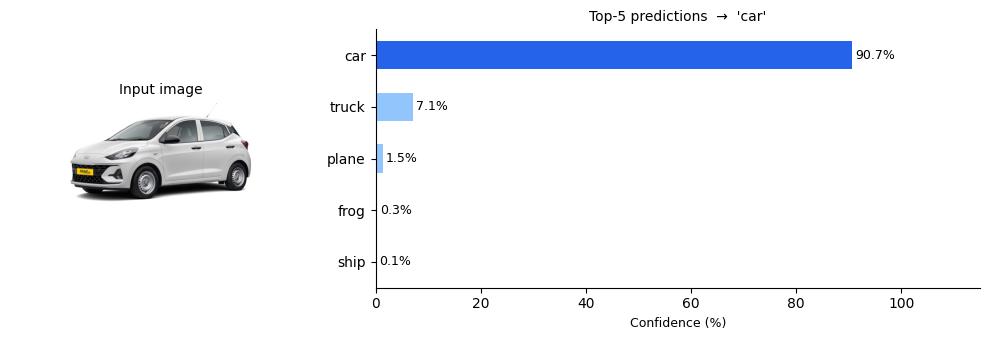


🏆  Prediction: CAR  (90.7% confidence)


In [35]:
IMAGE_URL = 'http://hyundai.com/content/dam/hyundai/in/en/data/find-a-car/Prime-hb/primehb-home-carousel.jpg'
# ↑ Change to any public image URL

response = requests.get(IMAGE_URL, timeout=10)
pil_img  = Image.open(io.BytesIO(response.content))
show_prediction(pil_img, topk=5)

Saving deer.jpeg to deer (1).jpeg


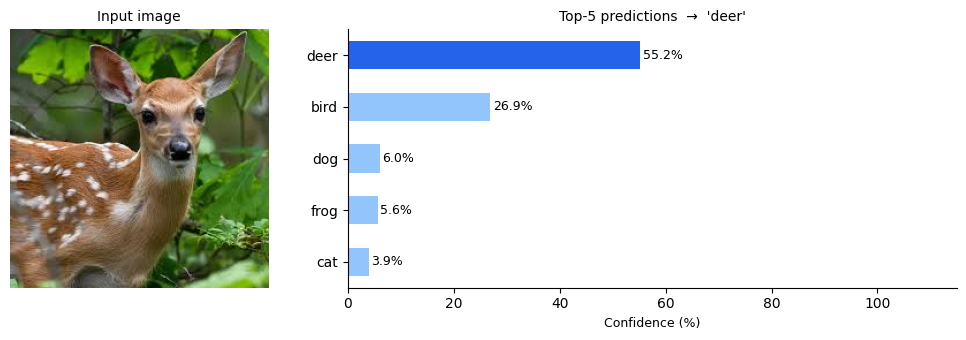


🏆  Prediction: DEER  (55.2% confidence)
Prediction complete!


In [33]:
from google.colab import files
from PIL import Image
import io

uploaded = files.upload()                   # opens file picker
fname = next(iter(uploaded))

pil_img = Image.open(io.BytesIO(uploaded[fname]))

show_prediction(pil_img, topk=5)

print('Prediction complete!')

## Section B: Data Augmentation Showcase

Visualise 8 augmentation strategies on the same raw image, then define a stronger training pipeline.

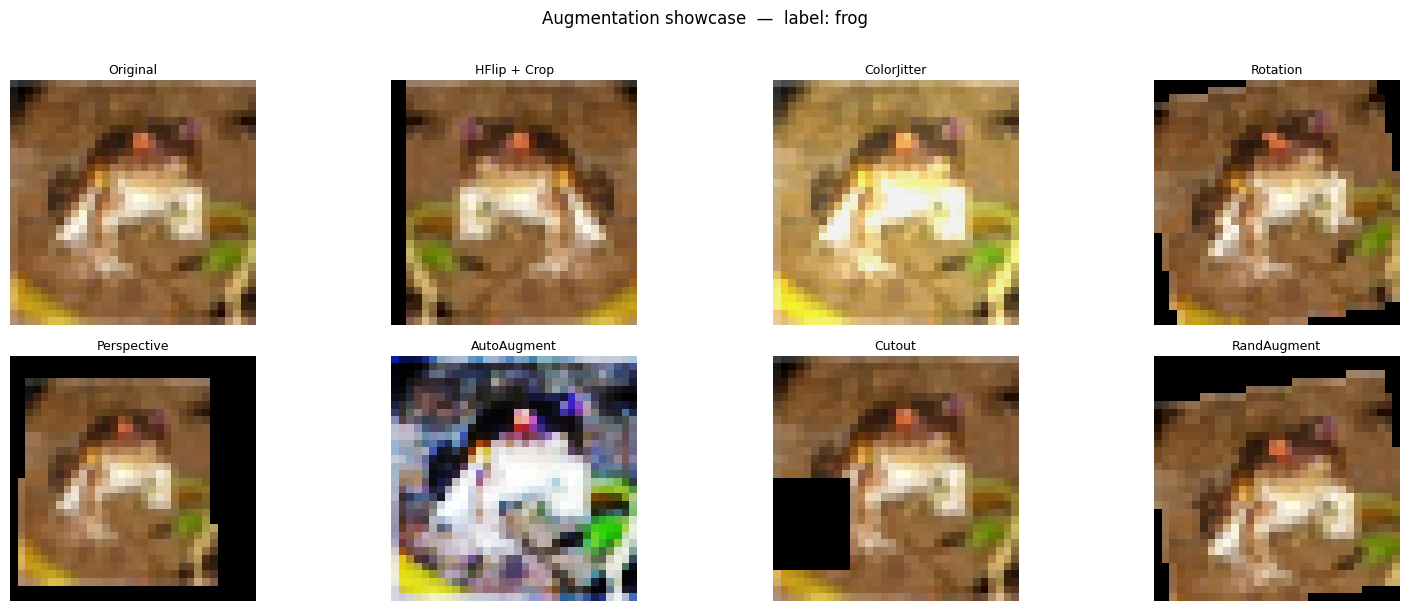

In [38]:
augmentations = {
    'Original':     transforms.Compose([transforms.ToTensor()]),
    'HFlip + Crop': transforms.Compose([
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor()]),
    'ColorJitter':  transforms.Compose([
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
        transforms.ToTensor()]),
    'Rotation':     transforms.Compose([
        transforms.RandomRotation(20),
        transforms.ToTensor()]),
    'Perspective':  transforms.Compose([
        transforms.RandomPerspective(distortion_scale=0.4, p=1.0),
        transforms.ToTensor()]),
    'AutoAugment':  transforms.Compose([
        transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10),
        transforms.ToTensor()]),
    'Cutout':       None,   # handled separately
    'RandAugment':  transforms.Compose([
        transforms.RandAugment(num_ops=2, magnitude=9),
        transforms.ToTensor()]),
}

def cutout(img_tensor, n_holes=1, length=12):
    t = img_tensor.clone()
    _, h, w = t.shape
    for _ in range(n_holes):
        cy, cx = np.random.randint(h), np.random.randint(w)
        y1, y2 = max(0, cy-length//2), min(h, cy+length//2)
        x1, x2 = max(0, cx-length//2), min(w, cx+length//2)
        t[:, y1:y2, x1:x2] = 0.0
    return t

raw_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                            download=False, transform=None)
raw_img, raw_lbl = raw_dataset[0]

n_aug = len(augmentations)
fig, axes = plt.subplots(2, math.ceil(n_aug/2), figsize=(16, 6))
for ax, (name, tfm) in zip(axes.flat, augmentations.items()):
    if name == 'Cutout':
        tensor = cutout(transforms.ToTensor()(raw_img))
    else:
        tensor = tfm(raw_img)
    ax.imshow(tensor.permute(1, 2, 0).numpy().clip(0, 1))
    ax.set_title(name, fontsize=9, pad=4)
    ax.axis('off')
for ax in list(axes.flat)[n_aug:]:
    ax.set_visible(False)

plt.suptitle(f'Augmentation showcase  —  label: {classes[raw_lbl]}', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [39]:
transform_strong = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

aug_trainset    = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                download=False, transform=transform_strong)
aug_trainloader = torch.utils.data.DataLoader(aug_trainset, batch_size=128,
                                               shuffle=True, num_workers=2)
print('Strong augmentation pipeline defined. Uncomment loader lines to retrain.')

Strong augmentation pipeline defined. Uncomment loader lines to retrain.


## Section C: Compare ViT vs CNN

Train a lightweight ResNet-style CNN with the same parameter budget and compare.

In [40]:
class SmallCNN(nn.Module):
    """Compact ResNet-inspired CNN for CIFAR-10 (~1.2M params)."""
    def __init__(self, num_classes=10):
        super().__init__()
        def block(ci, co, stride=1):
            return nn.Sequential(
                nn.Conv2d(ci, co, 3, stride=stride, padding=1, bias=False),
                nn.BatchNorm2d(co), nn.ReLU(inplace=True),
                nn.Conv2d(co, co, 3, padding=1, bias=False),
                nn.BatchNorm2d(co),
            )
        self.stem   = nn.Sequential(nn.Conv2d(3, 64, 3, padding=1, bias=False),
                                    nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.layer1 = block(64, 64)
        self.layer2 = block(64, 128, stride=2)
        self.layer3 = block(128, 256, stride=2)
        self.skip2  = nn.Sequential(nn.Conv2d(64, 128, 1, stride=2, bias=False),
                                    nn.BatchNorm2d(128))
        self.skip3  = nn.Sequential(nn.Conv2d(128, 256, 1, stride=2, bias=False),
                                    nn.BatchNorm2d(256))
        self.pool   = nn.AdaptiveAvgPool2d(1)
        self.fc     = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = F.relu(self.layer1(x) + x)
        x = F.relu(self.layer2(x) + self.skip2(x))
        x = F.relu(self.layer3(x) + self.skip3(x))
        return self.fc(self.pool(x).flatten(1))


cnn_model  = SmallCNN().to(device)
cnn_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
vit_params = sum(p.numel() for p in model.parameters()     if p.requires_grad)
print(f'CNN params : {cnn_params:,}')
print(f'ViT params : {vit_params:,}')

CNN params : 1,227,594
ViT params : 1,205,898


In [41]:
CNN_EPOCHS   = 20
cnn_criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.AdamW(cnn_model.parameters(), lr=3e-4, weight_decay=1e-4)
cnn_scheduler = optim.lr_scheduler.CosineAnnealingLR(cnn_optimizer, T_max=CNN_EPOCHS)

cnn_train_losses, cnn_test_accs = [], []

for epoch in range(1, CNN_EPOCHS + 1):
    cnn_model.train()
    running = 0.0
    for imgs, lbls in trainloader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        cnn_optimizer.zero_grad()
        loss = cnn_criterion(cnn_model(imgs), lbls)
        loss.backward()
        cnn_optimizer.step()
        running += loss.item()
    cnn_train_losses.append(running / len(trainloader))
    cnn_scheduler.step()

    cnn_model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in testloader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            _, pred = cnn_model(imgs).max(1)
            correct += pred.eq(lbls).sum().item()
            total   += lbls.size(0)
    acc = 100. * correct / total
    cnn_test_accs.append(acc)
    print(f'CNN Epoch [{epoch:2d}/{CNN_EPOCHS}]  '
          f'Loss: {cnn_train_losses[-1]:.4f}  Test Acc: {acc:.2f}%')

print('\nCNN training complete!')

CNN Epoch [ 1/20]  Loss: 1.4053  Test Acc: 57.53%
CNN Epoch [ 2/20]  Loss: 1.0067  Test Acc: 60.74%
CNN Epoch [ 3/20]  Loss: 0.8395  Test Acc: 68.90%
CNN Epoch [ 4/20]  Loss: 0.7369  Test Acc: 73.16%
CNN Epoch [ 5/20]  Loss: 0.6584  Test Acc: 70.32%
CNN Epoch [ 6/20]  Loss: 0.6014  Test Acc: 75.22%
CNN Epoch [ 7/20]  Loss: 0.5527  Test Acc: 77.56%
CNN Epoch [ 8/20]  Loss: 0.5123  Test Acc: 76.36%
CNN Epoch [ 9/20]  Loss: 0.4755  Test Acc: 80.65%
CNN Epoch [10/20]  Loss: 0.4423  Test Acc: 80.43%
CNN Epoch [11/20]  Loss: 0.4143  Test Acc: 82.43%
CNN Epoch [12/20]  Loss: 0.3834  Test Acc: 81.96%
CNN Epoch [13/20]  Loss: 0.3611  Test Acc: 84.22%
CNN Epoch [14/20]  Loss: 0.3386  Test Acc: 84.74%
CNN Epoch [15/20]  Loss: 0.3220  Test Acc: 85.42%
CNN Epoch [16/20]  Loss: 0.3016  Test Acc: 85.77%
CNN Epoch [17/20]  Loss: 0.2914  Test Acc: 86.35%
CNN Epoch [18/20]  Loss: 0.2759  Test Acc: 86.33%
CNN Epoch [19/20]  Loss: 0.2689  Test Acc: 86.44%
CNN Epoch [20/20]  Loss: 0.2661  Test Acc: 86.58%


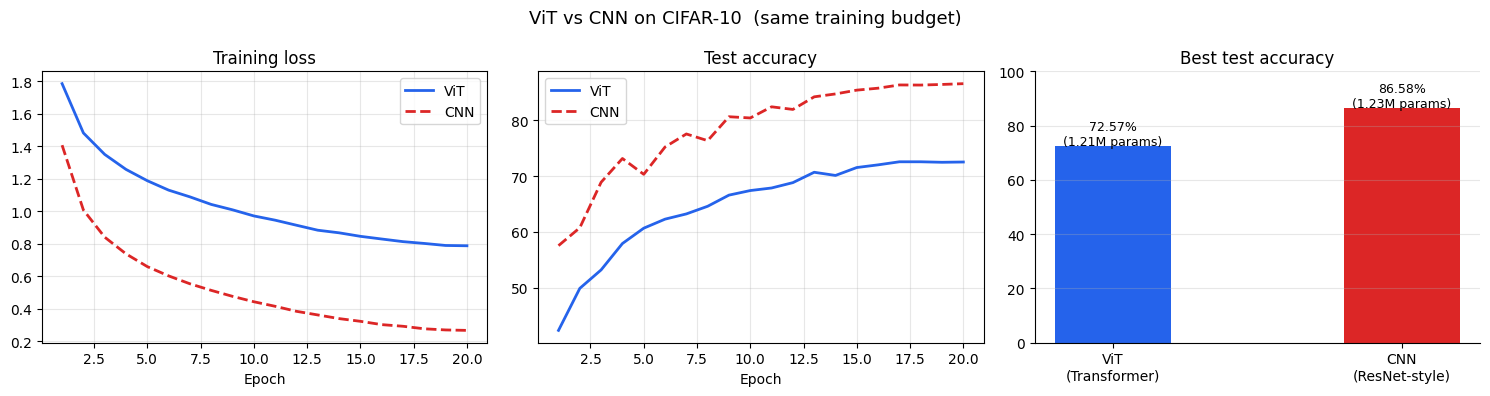

In [42]:
vit_train_losses = train_losses
vit_test_accs    = test_accuracies
epochs_x = list(range(1, CNN_EPOCHS + 1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_x, vit_train_losses, label='ViT', color='#2563eb', lw=2)
axes[0].plot(epochs_x, cnn_train_losses, label='CNN', color='#dc2626', lw=2, ls='--')
axes[0].set_title('Training loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, vit_test_accs, label='ViT', color='#2563eb', lw=2)
axes[1].plot(epochs_x, cnn_test_accs, label='CNN', color='#dc2626', lw=2, ls='--')
axes[1].set_title('Test accuracy'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

best_accs = [max(vit_test_accs), max(cnn_test_accs)]
params_m  = [vit_params/1e6, cnn_params/1e6]
bars = axes[2].bar(['ViT\n(Transformer)', 'CNN\n(ResNet-style)'],
                   best_accs, color=['#2563eb','#dc2626'], width=0.4, edgecolor='none')
for bar, acc, p in zip(bars, best_accs, params_m):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{acc:.2f}%\n({p:.2f}M params)', ha='center', fontsize=9)
axes[2].set_ylim(0, 100); axes[2].set_title('Best test accuracy')
axes[2].grid(axis='y', alpha=0.3)
axes[2].spines[['top','right']].set_visible(False)

plt.suptitle('ViT vs CNN on CIFAR-10  (same training budget)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Confusion Matrix

Full test-set evaluation: raw count heatmap, row-normalised heatmap, most confused pairs, and misclassified image examples.

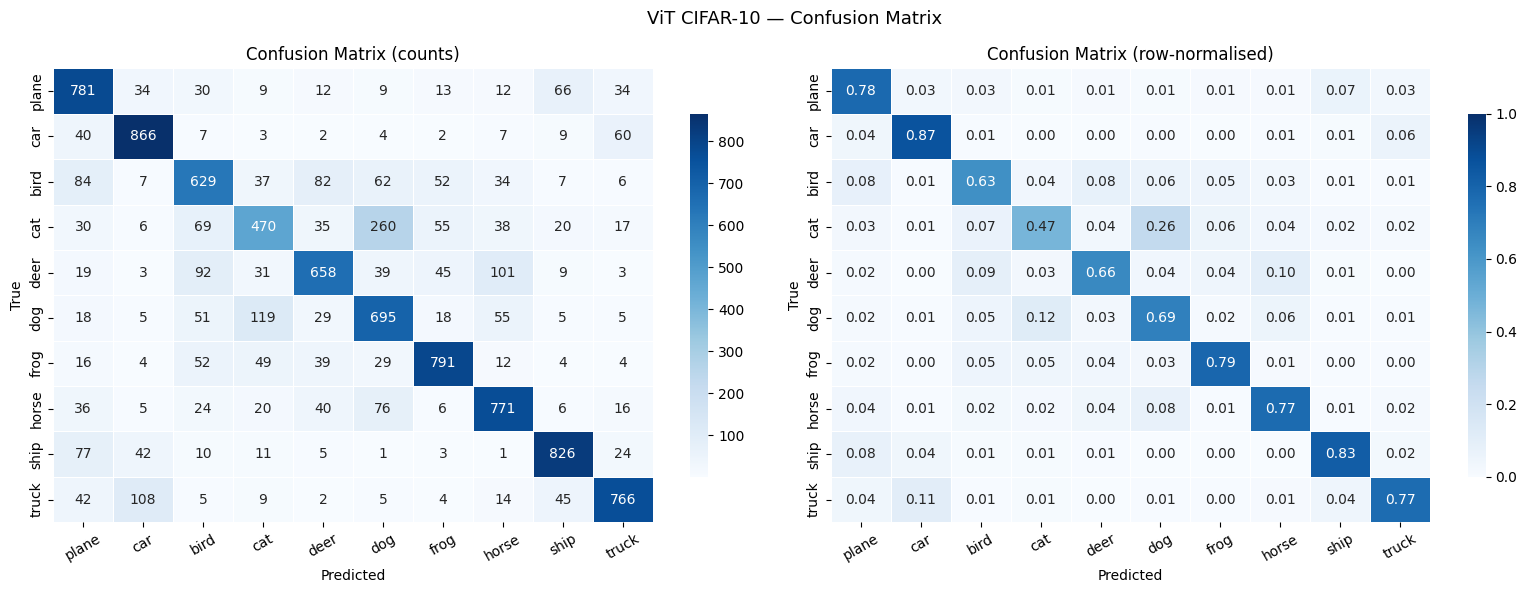


Most confused pairs (true → predicted):
      True   Predicted   Count
────────────────────────────────
       cat         dog     260
       dog         cat     119
     truck         car     108
      deer       horse     101
      deer        bird      92
      bird       plane      84


In [50]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

for name, module in model.named_modules():
    module._forward_hooks.clear()

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, lbls in testloader:
        imgs = imgs.to(device)
        _, pred = model(imgs).max(1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(lbls.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            ax=axes[0], linewidths=0.4, linecolor='white',
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Confusion Matrix (counts)', fontsize=12)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            ax=axes[1], vmin=0, vmax=1, linewidths=0.4, linecolor='white',
            cbar_kws={'shrink': 0.8})
axes[1].set_title('Confusion Matrix (row-normalised)', fontsize=12)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('ViT CIFAR-10 — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

cm_nodiag = cm.copy()
np.fill_diagonal(cm_nodiag, 0)
flat    = cm_nodiag.flatten()
top_idx = flat.argsort()[::-1][:6]

print('\nMost confused pairs (true → predicted):')
print(f'{"True":>10}  {"Predicted":>10}  {"Count":>6}')
print('─' * 32)
for idx in top_idx:
    t = classes[idx // len(classes)]
    p = classes[idx  % len(classes)]
    print(f'{t:>10}  {p:>10}  {flat[idx]:>6.0f}')